In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 03. Data Cleaning

## Objective

Prepare the raw retail sales dataset for downstream forecasting,
simulation, and optimization workflows.

The cleaning pipeline follows a validation-first approach:

1. Load the raw dataset.
2. Validate schema and data types.
3. Validate missing values and duplicates.
4. Validate business and temporal constraints.
5. Investigate potential anomalies.
6. Apply only justified transformations.
7. Save the processed dataset without modifying the raw source.

## 1. Initialization

In [3]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/ForecastOpti"
)

SRC_PATH = PROJECT_ROOT / "src"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"Source path : {SRC_PATH}")

Project root: /content/drive/MyDrive/ForecastOpti
Source path : /content/drive/MyDrive/ForecastOpti/src


In [4]:
from src.config import (
    DATASET_PATH,
    PROCESSED_DATA_DIR,
    SEED,
)

print(f"Raw dataset : {DATASET_PATH}")
print(f"Processed   : {PROCESSED_DATA_DIR}")
print(f"Seed        : {SEED}")

Raw dataset : /content/drive/MyDrive/ForecastOpti/data/raw/retail_sales.csv
Processed   : /content/drive/MyDrive/ForecastOpti/data/processed
Seed        : 42


## 2. Load Raw Dataset

In [5]:
df = pd.read_csv(
    DATASET_PATH,
    parse_dates=["date"],
)

print(f"Rows    : {len(df):,}")
print(f"Columns : {len(df.columns)}")
print(f"Memory  : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Rows    : 4,565,000
Columns : 8
Memory  : 699.35 MB


## 3. Schema Validation

Validate that the raw dataset contains the expected columns before
performing any transformation.

In [6]:
EXPECTED_COLUMNS = [
    "date",
    "store_id",
    "item_id",
    "sales",
    "price",
    "promo",
    "weekday",
    "month",
]

missing_columns = sorted(
    set(EXPECTED_COLUMNS) - set(df.columns)
)

unexpected_columns = sorted(
    set(df.columns) - set(EXPECTED_COLUMNS)
)

assert not missing_columns, (
    f"Missing columns: {missing_columns}"
)

assert not unexpected_columns, (
    f"Unexpected columns: {unexpected_columns}"
)

print("✓ Schema validation passed.")

✓ Schema validation passed.


In [7]:
assert list(df.columns) == EXPECTED_COLUMNS

print(" Column order validated.")

 Column order validated.


## 4. Data Type Normalization

In [8]:
df = df.astype({
    "store_id": "string",
    "item_id": "string",
    "sales": "int64",
    "price": "float64",
    "promo": "int8",
    "weekday": "int8",
    "month": "int8",
})
df.dtypes

,0
date,datetime64[ns]
store_id,string[python]
item_id,string[python]
sales,int64
price,float64
promo,int8
weekday,int8
month,int8


## 5. Missing Value Validation

In [9]:
missing_summary = (
    df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)

missing_summary["missing_rate"] = (
    missing_summary["missing_count"]
    / len(df)
)

display(missing_summary)

,missing_count,missing_rate
date,0,0.0
store_id,0,0.0
item_id,0,0.0
sales,0,0.0
price,0,0.0
promo,0,0.0
weekday,0,0.0
month,0,0.0


In [10]:
assert df.isna().sum().sum() == 0

print(" No missing values detected.")

 No missing values detected.


## 6. Duplicate Validation

In [11]:
duplicate_rows = df.duplicated().sum()

duplicate_keys = df.duplicated(
    subset=["date", "store_id", "item_id"]
).sum()

print(f"Duplicate rows               : {duplicate_rows:,}")
print(f"Duplicate store-item-date    : {duplicate_keys:,}")

Duplicate rows               : 0
Duplicate store-item-date    : 0


In [12]:
assert duplicate_rows == 0
assert duplicate_keys == 0

print(" Duplicate validation passed.")

 Duplicate validation passed.


In [13]:
sales_invalid = (
    df["sales"] < 0
).sum()

print(f"Negative sales: {sales_invalid:,}")

assert sales_invalid == 0

Negative sales: 0


In [14]:
price_invalid = (
    df["price"] <= 0
).sum()

print(f"Non-positive prices: {price_invalid:,}")

assert price_invalid == 0

Non-positive prices: 0


In [15]:
promo_invalid = (
    ~df["promo"].isin([0, 1])
).sum()

print(f"Invalid promo values: {promo_invalid:,}")

assert promo_invalid == 0

Invalid promo values: 0


In [16]:
weekday_invalid = (
    ~df["weekday"].between(0, 6)
).sum()

print(f"Invalid weekday values: {weekday_invalid:,}")

assert weekday_invalid == 0

Invalid weekday values: 0


In [17]:
month_invalid = (
    ~df["month"].between(1, 12)
).sum()

print(f"Invalid month values: {month_invalid:,}")

assert month_invalid == 0

Invalid month values: 0


In [18]:
weekday_mismatch = (
    df["weekday"]
    != df["date"].dt.dayofweek
).sum()

month_mismatch = (
    df["month"]
    != df["date"].dt.month
).sum()

print(f"Weekday mismatches : {weekday_mismatch:,}")
print(f"Month mismatches   : {month_mismatch:,}")

assert weekday_mismatch == 0
assert month_mismatch == 0

print(" Temporal consistency passed.")

Weekday mismatches : 0
Month mismatches   : 0
 Temporal consistency passed.


In [19]:
# Menghitung beberapa percentile sales untuk melihat distribusi demand
# dari nilai yang sangat rendah hingga nilai yang sangat tinggi.
sales_quantiles = df["sales"].quantile(
    [
        0.001,  # 0.1% data terbawah
        0.01,   # 1% data terbawah
        0.05,   # 5% data terbawah
        0.25,   # Kuartil pertama (Q1)
        0.50,   # Median (Q2)
        0.75,   # Kuartil ketiga (Q3)
        0.95,   # 95th percentile
        0.99,   # 99th percentile
        0.999,  # 99.9th percentile
    ]
)

# Menampilkan hasil percentile agar kita dapat melihat
# bagaimana nilai sales tersebar.
display(sales_quantiles)

,sales
0.001,2.0
0.010,6.0
0.050,10.0
0.250,18.0
0.500,27.0
0.750,38.0
0.950,57.0
0.990,73.0
0.999,97.0


## 7. Outlier Investigation

Outlier investigation is performed before applying any cleaning rule.

Extreme observations are not automatically removed because unusually
high or low values may represent valid business demand.

The investigation focuses on understanding the distribution and context
of extreme observations before defining a cleaning policy.

In [20]:
# Mengambil batas P99 dari distribusi sales.
# Nilai ini digunakan sebagai threshold untuk investigasi,
# bukan sebagai aturan untuk menghapus data.
sales_p99 = df["sales"].quantile(0.99)

# Memilih observasi yang sales-nya berada pada atau di atas P99.
# Kita hanya mengambil beberapa kolom yang relevan agar
# hasil investigasi mudah dibaca.
sales_extreme = df.loc[
    df["sales"] >= sales_p99,
    [
        "date",
        "store_id",
        "item_id",
        "sales",
        "price",
        "promo",
    ],
].copy()

# Menampilkan informasi dasar mengenai observasi dengan demand tinggi.
print(f"Sales P99 threshold : {sales_p99:.0f}")
print(f"High-demand rows    : {len(sales_extreme):,}")

# Menampilkan 20 observasi pertama untuk inspeksi manual.
display(sales_extreme.head(20))

Sales P99 threshold : 73
High-demand rows    : 50,125


,date,store_id,item_id,sales,price,promo
50,2019-02-20,store_1,item_1,82,17.04,1
78,2019-03-20,store_1,item_1,82,17.04,1
92,2019-04-03,store_1,item_1,85,17.04,1
126,2019-05-07,store_1,item_1,83,17.04,1
140,2019-05-21,store_1,item_1,80,17.04,1
141,2019-05-22,store_1,item_1,79,17.04,1
147,2019-05-28,store_1,item_1,78,17.04,1
148,2019-05-29,store_1,item_1,86,17.04,1
161,2019-06-11,store_1,item_1,74,17.04,1
371,2020-01-07,store_1,item_1,73,17.04,1


### 7.3 High-Demand and Promotion Relationship

Compare the promotion rate among high-demand observations with the
overall promotion rate.

This analysis helps determine whether unusually high sales values are
associated with promotional activity.

The comparison is descriptive and is not interpreted as a causal effect.

In [21]:
# Menghitung proporsi masing-masing nilai promo pada observasi
# dengan sales yang berada di atas atau sama dengan P99.
#
# normalize=True membuat hasil berupa proporsi, bukan jumlah baris.
high_demand_promo_rate = (
    sales_extreme["promo"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

# Menghitung promotion rate pada keseluruhan dataset sebagai
# baseline pembanding.
overall_promo_rate = (
    df["promo"]
    .mean()
    * 100
)

# Menghitung promotion rate khusus pada observasi high-demand.
high_demand_rate = (
    sales_extreme["promo"]
    .mean()
    * 100
)

# Menampilkan hasil agar kita dapat membandingkan kedua kelompok.
print(f"Overall promotion rate     : {overall_promo_rate:.2f}%")
print(f"High-demand promotion rate : {high_demand_rate:.2f}%")

# Menampilkan distribusi promo pada observasi high-demand.
display(high_demand_promo_rate)

Overall promotion rate     : 10.00%
High-demand promotion rate : 76.90%


,proportion
promo,
0,23.096259
1,76.903741


### 7.4 High-Demand Observation Review

Review representative high-demand observations together with their
date, store, item, price, and promotion status.

The purpose is to determine whether extreme sales values have plausible
business context before defining an outlier treatment policy.

In [22]:
# Mengurutkan observasi high-demand berdasarkan sales dari yang tertinggi.
# Tujuannya adalah melihat contoh demand paling ekstrem terlebih dahulu.
high_demand_review = (
    sales_extreme
    .sort_values(
        by="sales",
        ascending=False,
    )
)

# Menampilkan 20 observasi dengan sales tertinggi.
# Kolom yang ditampilkan sudah dipilih pada tahap sebelumnya
# agar pemeriksaan tetap fokus dan mudah dibaca.
display(
    high_demand_review.head(20)
)

,date,store_id,item_id,sales,price,promo
3140428,2023-03-15,store_35,item_20,139,16.16,1
3105769,2023-04-19,store_35,item_1,138,30.67,1
3140421,2023-03-08,store_35,item_20,136,16.16,1
1005834,2023-03-15,store_12,item_1,136,73.74,1
3014455,2023-04-05,store_34,item_1,135,13.03,1
3961785,2022-04-06,store_44,item_20,135,30.16,1
3961799,2022-04-20,store_44,item_20,134,30.16,1
3048792,2022-04-13,store_34,item_20,133,54.16,1
3014476,2023-04-26,store_34,item_1,133,13.03,1
1005519,2022-05-04,store_12,item_1,133,73.74,1


### 7.5 High-Demand Concentration by Item

Analyze the distribution of high-demand observations across items.

The objective is to determine whether extreme demand values are
concentrated in specific products or distributed across the product
catalog.

In [23]:
# Menghitung jumlah observasi high-demand untuk setiap item.
# Ini membantu kita melihat apakah extreme demand hanya muncul
# pada beberapa item tertentu.
high_demand_by_item = (
    sales_extreme["item_id"]
    .value_counts()
    .rename("high_demand_count")
    .to_frame()
)

# Menghitung total observasi untuk setiap item pada dataset utama.
# Nilai ini digunakan sebagai denominator untuk mendapatkan
# proporsi high-demand per item.
item_total_count = (
    df["item_id"]
    .value_counts()
    .rename("total_count")
)

# Menggabungkan jumlah high-demand dan jumlah observasi total
# berdasarkan item.
high_demand_by_item = (
    high_demand_by_item
    .join(item_total_count)
)

# Menghitung persentase observasi high-demand terhadap
# seluruh observasi item tersebut.
high_demand_by_item["high_demand_rate"] = (
    high_demand_by_item["high_demand_count"]
    / high_demand_by_item["total_count"]
    * 100
)

# Mengurutkan item berdasarkan jumlah high-demand terbanyak.
high_demand_by_item = (
    high_demand_by_item
    .sort_values(
        "high_demand_count",
        ascending=False,
    )
)

# Menampilkan seluruh item agar distribusinya dapat diperiksa.
display(high_demand_by_item)

,high_demand_count,total_count,high_demand_rate
item_id,,,
item_20,5492,91300,6.015334
item_1,5111,91300,5.598028
item_3,4453,91300,4.877327
item_6,3954,91300,4.330778
item_4,3409,91300,3.733844
item_39,3266,91300,3.577218
item_31,2858,91300,3.13034
item_13,2318,91300,2.538883
item_24,2151,91300,2.355969


### 7.6 Outlier Cleaning Policy

High-demand observations were investigated using distributional
thresholds and business context.

The investigation showed that:

- High-demand observations are strongly associated with promotion.
- Extreme sales values occur across multiple stores and items.
- High-demand observations are more frequent for items with higher
  baseline demand.
- No evidence of invalid or corrupted sales values was identified.

Therefore, valid extreme sales observations are retained.

No global percentile-based sales outlier removal is applied because
doing so could remove legitimate high-demand observations and distort
the demand distribution used for forecasting.

Future modeling steps may apply transformations or robust modeling
techniques when appropriate, but the raw demand observations remain
unchanged during data cleaning.

### 7.7 Price Validation

Validate the price variable for invalid numeric values.

The validation checks whether prices contain missing, infinite,
or non-positive values.

Price observations are not removed based solely on their magnitude,
because legitimate price variation may represent different products,
stores, or promotional conditions.

In [24]:
# Menghitung jumlah missing value pada kolom price.
# Nilai missing tidak boleh ada karena price akan digunakan
# sebagai salah satu fitur dalam proses forecasting.
price_missing = df["price"].isna().sum()

# Menghitung jumlah nilai infinite pada kolom price.
# Nilai inf dan -inf merupakan nilai numerik yang tidak valid
# untuk proses analisis maupun modeling.
price_infinite = (~np.isfinite(df["price"])).sum()

# Menghitung jumlah harga yang bernilai nol atau negatif.
# Untuk dataset retail ini, harga harus bernilai positif.
price_non_positive = (df["price"] <= 0).sum()

# Menampilkan hasil validasi price.
print(f"Missing prices       : {price_missing:,}")
print(f"Infinite prices      : {price_infinite:,}")
print(f"Non-positive prices  : {price_non_positive:,}")


Missing prices       : 0
Infinite prices      : 0
Non-positive prices  : 0


### 7.8 Price and Promotion Consistency

Compare price distributions between promotional and non-promotional
observations.

The objective is to understand whether promotion is associated with
different price levels and to verify that the price variable contains
plausible variation across promotion states.

This is a descriptive consistency check and does not assume that
promotion directly causes price changes.

In [25]:
# Menghitung statistik harga untuk masing-masing kondisi promo.
# Grouping berdasarkan promo memungkinkan kita membandingkan
# distribusi harga ketika promo aktif dan tidak aktif.
price_by_promo = (
    df.groupby("promo")["price"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max",
    )
)

# Menampilkan statistik harga berdasarkan status promo.
display(price_by_promo)

,count,mean,median,std,min,max
promo,,,,,,
0,4108506,55.092889,54.69,26.044529,10.02,99.99
1,456494,44.096169,43.87,20.851058,8.02,79.99


### 7.9 Price Consistency by Item

Analyze price variation within each item.

Because different items naturally have different price levels,
price validation should be performed within item rather than across
the entire dataset.

The objective is to identify whether individual items have unusually
large or inconsistent price variation that may indicate data quality
issues.

In [26]:
# Mengelompokkan data berdasarkan item.
# Setiap item dianalisis secara terpisah karena setiap produk
# memiliki rentang harga yang berbeda.
item_price_summary = (
    df.groupby("item_id")["price"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max",
    )
)

# Menghitung rentang harga setiap item.
# Rentang digunakan untuk melihat seberapa besar variasi harga
# yang terjadi pada masing-masing produk.
item_price_summary["price_range"] = (
    item_price_summary["max"]
    - item_price_summary["min"]
)

# Mengurutkan item berdasarkan rentang harga terbesar.
# Ini membantu kita memeriksa item dengan variasi harga paling tinggi.
item_price_summary = (
    item_price_summary
    .sort_values(
        "price_range",
        ascending=False,
    )
)

# Menampilkan ringkasan harga seluruh item.
display(item_price_summary)

,count,mean,median,std,min,max,price_range
item_id,,,,,,,
item_20,91300,55.302050,56.09,23.220325,8.10,99.81,91.71
item_47,91300,52.983126,49.54,28.404951,8.09,99.79,91.70
item_3,91300,54.592158,60.23,28.449228,8.02,99.51,91.49
item_33,91300,56.492111,49.92,27.452049,8.19,99.42,91.23
item_43,91300,53.932689,51.32,26.157515,8.63,99.74,91.11
item_9,91300,55.121288,49.64,27.851051,8.09,99.18,91.09
item_30,91300,56.274884,57.85,28.067814,8.69,99.77,91.08
item_45,91300,54.050150,55.27,22.972381,8.47,99.54,91.07
item_38,91300,46.327276,44.84,24.818353,8.96,99.89,90.93


### 7.10 Price Variation Over Time

Inspect price changes over time for individual items.

Price variation is expected in a multi-year retail dataset. The objective
is to verify that price changes occur across valid dates and do not appear
as isolated or structurally invalid observations.

In [27]:
# Memilih satu item sebagai contoh untuk inspeksi perubahan harga.
selected_item = "item_20"

# Mengambil data untuk item yang dipilih.
# store_id ikut disertakan karena harga harus dibandingkan
# pada store yang sama, bukan antar-store.
item_price_history = (
    df.loc[
        df["item_id"] == selected_item,
        [
            "date",
            "store_id",
            "item_id",
            "price",
            "promo",
        ],
    ]
    .sort_values(
        ["store_id", "date"]
    )
    .copy()
)

# Menghitung perubahan harga terhadap observasi sebelumnya
# untuk store yang sama.
#
# groupby("store_id") memastikan harga tidak dibandingkan
# antara store yang berbeda.
item_price_history["price_change"] = (
    item_price_history
    .groupby("store_id")["price"]
    .diff()
)

# Menampilkan histori harga untuk beberapa observasi pertama.
display(
    item_price_history.head(20)
)

,date,store_id,item_id,price,promo,price_change
34694,2019-01-01,store_1,item_20,15.24,0,NaN
34695,2019-01-02,store_1,item_20,15.24,0,0.00
34696,2019-01-03,store_1,item_20,12.20,1,-3.04
34697,2019-01-04,store_1,item_20,15.24,0,3.04
34698,2019-01-05,store_1,item_20,15.24,0,0.00
34699,2019-01-06,store_1,item_20,15.24,0,0.00
34700,2019-01-07,store_1,item_20,12.20,1,-3.04
34701,2019-01-08,store_1,item_20,15.24,0,3.04
34702,2019-01-09,store_1,item_20,15.24,0,0.00
34703,2019-01-10,store_1,item_20,15.24,0,0.00


### 7.11 Price Behavior During Promotion

Compare the average price between promotional and non-promotional
observations for each item.

The objective is to determine whether promotional periods are
associated with systematic price changes within individual items.

This analysis is descriptive and is used to support data validation,
not to establish causal relationships.

In [28]:
# Menghitung rata-rata harga untuk setiap kombinasi item dan
# promotion status.
#
# Grouping berdasarkan item_id memastikan harga dibandingkan
# dalam produk yang sama.
item_promo_price = (
    df.groupby(
        ["item_id", "promo"]
    )["price"]
    .mean()
    .unstack("promo")
)

# Memberikan nama kolom yang lebih deskriptif.
# Kolom 0 berarti harga rata-rata ketika tidak ada promo,
# sedangkan kolom 1 berarti harga rata-rata ketika promo aktif.
item_promo_price = item_promo_price.rename(
    columns={
        0: "no_promo_mean_price",
        1: "promo_mean_price",
    }
)

# Menghitung persentase perubahan harga selama promo
# dibandingkan dengan harga rata-rata tanpa promo.
item_promo_price["price_change_pct"] = (
    (
        item_promo_price["promo_mean_price"]
        - item_promo_price["no_promo_mean_price"]
    )
    / item_promo_price["no_promo_mean_price"]
    * 100
)

# Mengurutkan item berdasarkan perubahan harga paling besar.
item_promo_price = (
    item_promo_price
    .sort_values(
        "price_change_pct",
        ascending=True,
    )
)

# Menampilkan hasil untuk seluruh item.
display(item_promo_price)

promo,no_promo_mean_price,promo_mean_price,price_change_pct
item_id,,,
item_18,48.583986,38.296499,-21.174645
item_40,55.899226,44.292316,-20.763991
item_31,57.824813,45.838352,-20.728922
item_15,58.314471,46.287281,-20.624708
item_9,56.250396,44.729662,-20.481159
item_36,55.541946,44.217049,-20.389809
item_28,58.801957,46.821621,-20.374042
item_39,57.987185,46.188837,-20.346475
item_8,51.093714,40.704426,-20.333789


# 10. EDA Conclusion and Modeling Decisions

The dataset has passed the main data quality and consistency checks.

Key findings:

- The dataset contains 4,565,000 observations from 50 stores and 50 items.
- The time period covers 2019-01-01 to 2023-12-31.
- No missing calendar dates were detected.
- No duplicate store-item-date combinations were detected.
- Calendar features `weekday` and `month` are temporally consistent.
- Sales demand shows clear weekly and monthly patterns.
- Demand varies across items and stores.
- Promotional observations are associated with substantially higher demand.
- Promotional periods are also associated with lower prices.
- Price and promotion therefore provide useful information for demand forecasting.
- Extreme demand observations are retained because they can represent genuine high-demand events.

Modeling implications:

1. `sales` will be used as the forecasting target.
2. `price` and `promo` will be retained as explanatory features.
3. `weekday` and `month` will be retained as calendar features.
4. The time dimension must be respected when creating train, validation, and test sets.
5. No random train-test split will be used for the forecasting task.
6. No arbitrary removal of high-demand observations will be performed.

# 11. Data Preparation for Forecasting

Prepare the validated dataset for time-series forecasting.

The preparation stage will focus on:

- ensuring the data is sorted chronologically,
- defining the forecasting target,
- preserving relevant explanatory features,
- and preparing the dataset for a time-based train, validation, and test split.

No random shuffling will be applied because the temporal order of the observations must be preserved.

In [29]:
# Membuat salinan dataset agar data asli tetap tidak berubah.
forecast_df = df.copy()

# Mengurutkan data berdasarkan store, item, dan tanggal.
# Urutan ini penting karena forecasting membutuhkan urutan waktu
# yang benar untuk setiap kombinasi store dan item.
forecast_df = forecast_df.sort_values(
    ["store_id", "item_id", "date"]
).reset_index(drop=True)

# Menampilkan lima baris pertama setelah proses sorting.
display(forecast_df.head())

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1


### 11.1 Define Forecast Target

The forecasting target is daily `sales`.

The model will learn to predict future sales for each
store-item combination.

The original sales column is preserved as the target variable,
while `price`, `promo`, `weekday`, and `month` are retained as
potential explanatory features.

In [30]:
# Menentukan nama kolom yang akan menjadi target forecasting.
# Target adalah nilai yang ingin diprediksi oleh model.
TARGET_COLUMN = "sales"

# Menentukan fitur yang akan digunakan sebagai informasi
# untuk membantu model memprediksi demand.
FEATURE_COLUMNS = [
    "price",
    "promo",
    "weekday",
    "month",
]

# Memastikan kolom target dan seluruh fitur tersedia
# di dalam dataset yang sudah disiapkan.
required_columns = [
    TARGET_COLUMN,
    *FEATURE_COLUMNS,
]

missing_columns = [
    column
    for column in required_columns
    if column not in forecast_df.columns
]

# Jika ada kolom yang hilang, proses akan dihentikan
# sehingga kita tidak melanjutkan dengan struktur data yang salah.
if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

# Menampilkan konfigurasi target dan fitur
# agar kita dapat memverifikasi keputusan sebelum modeling.
print("Forecast target :", TARGET_COLUMN)
print("Features        :", FEATURE_COLUMNS)

Forecast target : sales
Features        : ['price', 'promo', 'weekday', 'month']


### 11.2 Time-Based Train / Validation / Test Split

Split the dataset chronologically into training, validation, and test
sets.

- Training data: 2019-01-01 to 2022-12-31
- Validation data: 2023-01-01 to 2023-06-30
- Test data: 2023-07-01 to 2023-12-31

The chronological order is preserved to prevent future information
from leaking into the training process.

In [31]:
# Menentukan batas akhir untuk masing-masing dataset.
# Batas waktu ini digunakan agar pembagian data mengikuti
# urutan kronologis.
train_end = "2022-12-31"
validation_end = "2023-06-30"

# Membuat training set.
# Data training mencakup seluruh periode dari awal dataset
# sampai akhir tahun 2022.
train_df = forecast_df[
    forecast_df["date"] <= train_end
].copy()

# Membuat validation set.
# Validation digunakan untuk mengevaluasi dan memilih model
# sebelum melakukan evaluasi final pada test set.
validation_df = forecast_df[
    (forecast_df["date"] > train_end)
    & (forecast_df["date"] <= validation_end)
].copy()

# Membuat test set.
# Test set berisi periode waktu paling akhir dan hanya digunakan
# untuk evaluasi final model.
test_df = forecast_df[
    forecast_df["date"] > validation_end
].copy()

# Menampilkan jumlah observasi pada masing-masing subset.
print(f"Train rows      : {len(train_df):,}")
print(f"Validation rows : {len(validation_df):,}")
print(f"Test rows       : {len(test_df):,}")

Train rows      : 3,652,500
Validation rows : 452,500
Test rows       : 460,000


### 11.3 Validate Time Split

Validate the chronological boundaries of the training, validation,
and test datasets.

The objective is to confirm that:

- training data contains only historical observations,
- validation data occurs after training data,
- test data occurs after validation data,
- and there is no temporal overlap between the three datasets.

In [32]:
# Mengambil tanggal minimum dan maksimum dari setiap subset.
# Ini digunakan untuk memastikan bahwa pembagian data
# benar-benar mengikuti urutan waktu.
split_summary = pd.DataFrame(
    {
        "dataset": [
            "train",
            "validation",
            "test",
        ],
        "start_date": [
            train_df["date"].min(),
            validation_df["date"].min(),
            test_df["date"].min(),
        ],
        "end_date": [
            train_df["date"].max(),
            validation_df["date"].max(),
            test_df["date"].max(),
        ],
        "rows": [
            len(train_df),
            len(validation_df),
            len(test_df),
        ],
    }
)

# Menampilkan ringkasan periode setiap dataset.
display(split_summary)

,dataset,start_date,end_date,rows
0,train,2019-01-01,2022-12-31,3652500
1,validation,2023-01-01,2023-06-30,452500
2,test,2023-07-01,2023-12-31,460000


### 11.4 Prepare Features and Target

Separate the explanatory features from the forecasting target.

The target variable is `sales`, while the selected explanatory
features are `price`, `promo`, `weekday`, and `month`.

The same feature structure is applied consistently to the training,
validation, and test datasets.

In [33]:
# Mengambil fitur dari training set.
# X berisi informasi yang akan digunakan model untuk melakukan prediksi.
X_train = train_df[FEATURE_COLUMNS].copy()

# Mengambil target dari training set.
# y berisi nilai sales yang ingin diprediksi oleh model.
y_train = train_df[TARGET_COLUMN].copy()

# Mengambil fitur dari validation set.
# Validation digunakan untuk mengevaluasi model selama proses pengembangan.
X_validation = validation_df[FEATURE_COLUMNS].copy()

# Mengambil target validation sebagai nilai pembanding
# terhadap hasil prediksi model.
y_validation = validation_df[TARGET_COLUMN].copy()

# Mengambil fitur dari test set.
# Test set hanya digunakan untuk evaluasi final.
X_test = test_df[FEATURE_COLUMNS].copy()

# Mengambil target test sebagai ground truth untuk evaluasi akhir.
y_test = test_df[TARGET_COLUMN].copy()

# Menampilkan ukuran masing-masing feature matrix dan target vector.
print("X_train      :", X_train.shape)
print("y_train      :", y_train.shape)

print("X_validation :", X_validation.shape)
print("y_validation :", y_validation.shape)

print("X_test       :", X_test.shape)
print("y_test       :", y_test.shape)

X_train      : (3652500, 4)
y_train      : (3652500,)
X_validation : (452500, 4)
y_validation : (452500,)
X_test       : (460000, 4)
y_test       : (460000,)


### 11.5 Feature Data Type Validation

Validate the data types of the selected forecasting features and
target variable before model training.

The objective is to confirm that the features and target contain
numeric values suitable for machine learning models.

In [34]:
# Menampilkan tipe data dari seluruh fitur training.
# Setiap fitur harus memiliki tipe numerik agar dapat digunakan
# oleh sebagian besar machine learning models.
print("Feature dtypes:")
display(X_train.dtypes)

# Menampilkan tipe data dari target.
# Target sales juga harus berupa tipe numerik.
print("\nTarget dtype:")
print(y_train.dtype)

Feature dtypes:


,0
price,float64
promo,int8
weekday,int8
month,int8



Target dtype:
int64


### 11.6 Final Missing-Value Check

Perform a final missing-value check on the feature matrices and
target vectors before model training.

This ensures that the exact data passed to the forecasting model
does not contain missing observations.

In [35]:
# Menghitung jumlah missing value pada setiap fitur training.
# Training set adalah data utama yang akan digunakan untuk melatih model.
print("Missing values in X_train:")
display(X_train.isna().sum())

# Memeriksa missing value pada target training.
print("\nMissing values in y_train:")
print(y_train.isna().sum())

# Memeriksa validation set.
print("\nMissing values in X_validation:")
display(X_validation.isna().sum())

print("\nMissing values in y_validation:")
print(y_validation.isna().sum())

# Memeriksa test set.
print("\nMissing values in X_test:")
display(X_test.isna().sum())

print("\nMissing values in y_test:")
print(y_test.isna().sum())

Missing values in X_train:


,0
price,0
promo,0
weekday,0
month,0



Missing values in y_train:
0

Missing values in X_validation:


,0
price,0
promo,0
weekday,0
month,0



Missing values in y_validation:
0

Missing values in X_test:


,0
price,0
promo,0
weekday,0
month,0



Missing values in y_test:
0


### 11.8 Baseline Evaluation

Evaluate the baseline prediction on the validation set.

The baseline predicts the training-set mean sales for every validation
observation.

This baseline provides a reference point for evaluating whether the
machine learning model can learn useful demand patterns.

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calculate the mean sales from the training set for baseline prediction.
baseline_prediction = y_train.mean()

# Menggunakan nilai rata-rata sales dari training sebagai
# prediksi untuk setiap observasi pada validation set.
baseline_validation_pred = [baseline_prediction] * len(y_validation)

# Menghitung Mean Absolute Error (MAE).
# MAE menunjukkan rata-rata selisih absolut antara sales aktual
# dan sales yang diprediksi.
baseline_mae = mean_absolute_error(
    y_validation,
    baseline_validation_pred,
)

# Menghitung Root Mean Squared Error (RMSE).
# RMSE memberikan penalti lebih besar terhadap kesalahan prediksi
# yang besar dibandingkan MAE.
baseline_rmse = mean_squared_error(
    y_validation,
    baseline_validation_pred,
) ** 0.5

# Menampilkan hasil evaluasi baseline.
print(f"Baseline MAE  : {baseline_mae:.4f}")
print(f"Baseline RMSE : {baseline_rmse:.4f}")

Baseline MAE  : 15.3451
Baseline RMSE : 20.0150


### 11.9 Model 1 — Random Forest

Train a Random Forest regression model using the prepared
forecasting features.

The model will learn the relationship between:

- `price`
- `promo`
- `weekday`
- `month`

and the target variable `sales`.

The model will be trained only on the training dataset.
Validation data will be used only to evaluate the model.

In [37]:
# Mengimpor Random Forest Regressor dari scikit-learn.
# Random Forest terdiri dari banyak decision tree yang digabungkan
# untuk menghasilkan prediksi yang lebih stabil.
from sklearn.ensemble import RandomForestRegressor

# Membuat model Random Forest.
#
# n_estimators:
# Jumlah decision tree yang digunakan oleh Random Forest.
#
# max_depth:
# Membatasi kedalaman tree agar model tidak terlalu kompleks.
#
# random_state:
# Menjaga hasil eksperimen tetap reproducible.
#
# n_jobs=-1:
# Menggunakan seluruh CPU yang tersedia agar proses training
# dapat berjalan lebih cepat.
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    random_state=SEED,
    n_jobs=-1,
)

# Melatih model hanya menggunakan training data.
# Model tidak melihat validation atau test data pada tahap ini.
rf_model.fit(
    X_train,
    y_train,
)

print("Random Forest training completed.")

Random Forest training completed.


In [38]:
# Menghasilkan prediksi sales untuk seluruh observasi
# pada validation set menggunakan Random Forest yang sudah dilatih.
rf_validation_pred = rf_model.predict(X_validation)

# Menghitung Mean Absolute Error (MAE).
# Nilai yang lebih kecil menunjukkan prediksi yang lebih akurat.
rf_mae = mean_absolute_error(
    y_validation,
    rf_validation_pred,
)

# Menghitung Root Mean Squared Error (RMSE).
# RMSE memberikan penalti lebih besar terhadap error yang besar.
rf_rmse = mean_squared_error(
    y_validation,
    rf_validation_pred,
) ** 0.5

# Menghitung improvement MAE terhadap baseline.
# Nilai positif menunjukkan bahwa Random Forest
# memiliki MAE lebih kecil daripada baseline.
mae_improvement = (
    (baseline_mae - rf_mae)
    / baseline_mae
    * 100
)

# Menghitung improvement RMSE terhadap baseline.
# Nilai positif menunjukkan bahwa Random Forest
# memiliki RMSE lebih kecil daripada baseline.
rmse_improvement = (
    (baseline_rmse - rf_rmse)
    / baseline_rmse
    * 100
)

# Menampilkan hasil evaluasi Random Forest.
print(f"Random Forest MAE  : {rf_mae:.4f}")
print(f"Random Forest RMSE : {rf_rmse:.4f}")

# Menampilkan perbandingan performa terhadap baseline.
print(f"\nMAE improvement    : {mae_improvement:.2f}%")
print(f"RMSE improvement   : {rmse_improvement:.2f}%")

Random Forest MAE  : 13.0434
Random Forest RMSE : 15.8843

MAE improvement    : 15.00%
RMSE improvement   : 20.64%


### 11.10 Model Comparison

The Random Forest model improves substantially over the mean-sales
baseline on the validation dataset.

The Random Forest achieves:

- MAE: 13.0434, compared with 15.3451 for the baseline.
- RMSE: 15.8843, compared with 20.0150 for the baseline.

This corresponds to an improvement of approximately:

- 15.00% in MAE.
- 20.64% in RMSE.

The result indicates that the selected explanatory features contain
useful information for predicting daily sales.

The Random Forest will therefore be retained as the first machine
learning benchmark for comparison with subsequent models.

In [39]:
# Membuat tabel hasil eksperimen model.
# Tabel ini akan menjadi tempat menyimpan performa setiap model
# sehingga kita dapat membandingkannya secara konsisten.
model_results = pd.DataFrame(
    [
        {
            "model": "Baseline",
            "MAE": baseline_mae,
            "RMSE": baseline_rmse,
        },
        {
            "model": "Random Forest",
            "MAE": rf_mae,
            "RMSE": rf_rmse,
        },
    ]
)

# Menampilkan hasil perbandingan model.
display(model_results)

,model,MAE,RMSE
0,Baseline,15.345116,20.015027
1,Random Forest,13.043365,15.884275


### 11.12 Model 2 — HistGradientBoosting

Train a HistGradientBoosting regression model as the second
machine-learning benchmark.

Unlike Random Forest, which builds many trees independently,
Gradient Boosting builds trees sequentially.

Each new tree attempts to reduce the errors made by the previous
trees.

The model will be trained only on the training dataset and evaluated
later using the validation dataset.

In [40]:
# Mengimpor HistGradientBoostingRegressor dari scikit-learn.
# Model ini menggunakan gradient boosting berbasis decision tree.
from sklearn.ensemble import HistGradientBoostingRegressor

# Membuat model HistGradientBoosting.
#
# max_iter:
# Jumlah maksimum boosting iteration.
#
# learning_rate:
# Mengontrol seberapa besar kontribusi setiap tree terhadap model.
# Nilai yang lebih kecil biasanya membuat proses belajar lebih hati-hati.
#
# max_leaf_nodes:
# Membatasi kompleksitas setiap tree.
#
# random_state:
# Membuat hasil eksperimen dapat direproduksi.
hgb_model = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.08,
    max_leaf_nodes=31,
    random_state=SEED,
)

# Melatih model hanya menggunakan training data.
# Validation dan test tidak digunakan dalam proses training.
hgb_model.fit(
    X_train,
    y_train,
)

# Menampilkan informasi bahwa training telah selesai.
print("HistGradientBoosting training completed.")

HistGradientBoosting training completed.


In [41]:
# Menghasilkan prediksi sales untuk validation set
# menggunakan HistGradientBoosting yang sudah dilatih.
hgb_validation_pred = hgb_model.predict(X_validation)

# Menghitung Mean Absolute Error (MAE).
# Semakin kecil nilainya, semakin kecil rata-rata error prediksi.
hgb_mae = mean_absolute_error(
    y_validation,
    hgb_validation_pred,
)

# Menghitung Root Mean Squared Error (RMSE).
# Metric ini lebih sensitif terhadap error prediksi yang besar.
hgb_rmse = mean_squared_error(
    y_validation,
    hgb_validation_pred,
) ** 0.5

# Menghitung improvement terhadap baseline.
# Nilai positif berarti model lebih baik daripada baseline.
hgb_mae_improvement = (
    (baseline_mae - hgb_mae)
    / baseline_mae
    * 100
)

hgb_rmse_improvement = (
    (baseline_rmse - hgb_rmse)
    / baseline_rmse
    * 100
)

# Menampilkan hasil evaluasi HistGradientBoosting.
print(f"HistGradientBoosting MAE  : {hgb_mae:.4f}")
print(f"HistGradientBoosting RMSE : {hgb_rmse:.4f}")

# Menampilkan persentase improvement terhadap baseline.
print(f"\nMAE improvement            : {hgb_mae_improvement:.2f}%")
print(f"RMSE improvement           : {hgb_rmse_improvement:.2f}%")

HistGradientBoosting MAE  : 12.7804
HistGradientBoosting RMSE : 15.6073

MAE improvement            : 16.71%
RMSE improvement           : 22.02%


### 11.14 Model Comparison

Compare the validation performance of all models trained so far.

The validation set is used to select the best model, while the test set
remains untouched until the final evaluation.

The model with the lowest MAE and RMSE will be considered the current
best candidate.

In [42]:
# Menambahkan hasil HistGradientBoosting ke tabel perbandingan model.
model_results = pd.concat(
    [
        model_results,
        pd.DataFrame(
            [
                {
                    "model": "HistGradientBoosting",
                    "MAE": hgb_mae,
                    "RMSE": hgb_rmse,
                }
            ]
        ),
    ],
    ignore_index=True,
)

# Mengurutkan model berdasarkan MAE dari yang paling kecil.
# MAE yang lebih kecil berarti rata-rata error prediksi lebih rendah.
model_results = model_results.sort_values(
    "MAE",
    ascending=True,
).reset_index(drop=True)

# Menampilkan perbandingan seluruh model.
display(model_results)

,model,MAE,RMSE
0,HistGradientBoosting,12.780353,15.607264
1,Random Forest,13.043365,15.884275
2,Baseline,15.345116,20.015027


### 11.15 Candidate Model Selection

HistGradientBoosting achieves the lowest MAE and RMSE on the validation
dataset among the models evaluated so far.

It is therefore selected as the current candidate model for the final
evaluation.

The test dataset has not been used for model selection and remains
untouched until the final evaluation stage.

In [43]:
# Mengambil nama model dengan MAE validation paling rendah.
# MAE digunakan sebagai metric utama untuk memilih candidate model.
best_model_name = model_results.loc[
    model_results["MAE"].idxmin(),
    "model",
]

# Menampilkan model yang terpilih.
print(f"Selected candidate model : {best_model_name}")

Selected candidate model : HistGradientBoosting


### 11.16 Final Test Evaluation

Evaluate the selected HistGradientBoosting model on the test dataset.

The test dataset was not used during model training or model selection.
Therefore, this evaluation provides the final estimate of model
performance on unseen future observations.

MAE and RMSE are used as the primary evaluation metrics.

In [44]:
# Menghasilkan prediksi sales untuk test set menggunakan
# HistGradientBoosting model yang telah dipilih berdasarkan
# performa pada validation set.
hgb_test_pred = hgb_model.predict(X_test)

# Menghitung Mean Absolute Error (MAE) pada test set.
# Nilai ini menunjukkan rata-rata besar kesalahan prediksi
# dalam satuan sales.
test_mae = mean_absolute_error(
    y_test,
    hgb_test_pred,
)

# Menghitung Root Mean Squared Error (RMSE) pada test set.
# RMSE memberikan penalti lebih besar terhadap error yang besar.
test_rmse = mean_squared_error(
    y_test,
    hgb_test_pred,
) ** 0.5

# Menampilkan hasil evaluasi final pada test set.
print(f"Final Test MAE  : {test_mae:.4f}")
print(f"Final Test RMSE : {test_rmse:.4f}")

Final Test MAE  : 8.9771
Final Test RMSE : 11.0677


### 11.17 Validation vs Test Performance

Compare the performance of the selected HistGradientBoosting model
between the validation and test datasets.

This comparison helps us understand whether the model maintains
consistent performance on unseen future observations.

A lower test error than validation error is not automatically a problem,
but a substantial difference should be investigated before drawing
final conclusions.

In [45]:
# Menghitung perubahan MAE dari validation ke test.
# Nilai positif berarti MAE pada test lebih rendah daripada validation.
mae_test_improvement = (
    (hgb_mae - test_mae)
    / hgb_mae
    * 100
)

# Menghitung perubahan RMSE dari validation ke test.
# Nilai positif berarti RMSE pada test lebih rendah daripada validation.
rmse_test_improvement = (
    (hgb_rmse - test_rmse)
    / hgb_rmse
    * 100
)

# Membuat tabel agar perbandingan validation dan test
# lebih mudah dibaca.
final_comparison = pd.DataFrame(
    [
        {
            "dataset": "Validation",
            "MAE": hgb_mae,
            "RMSE": hgb_rmse,
        },
        {
            "dataset": "Test",
            "MAE": test_mae,
            "RMSE": test_rmse,
        },
    ]
)

# Menampilkan tabel perbandingan.
display(final_comparison)

# Menampilkan persentase perbedaan performa.
print(f"Test MAE improvement  : {mae_test_improvement:.2f}%")
print(f"Test RMSE improvement : {rmse_test_improvement:.2f}%")

,dataset,MAE,RMSE
0,Validation,12.780353,15.607264
1,Test,8.977142,11.067669


Test MAE improvement  : 29.76%
Test RMSE improvement : 29.09%


### 11.18 Validation vs Test Demand Distribution

Compare the target sales distribution between the validation and test
periods.

This check helps determine whether the difference in model performance
may be related to a change in demand level between the two periods.

The comparison uses the actual `sales` values and does not modify the
model or datasets.

In [46]:
# Menghitung statistik dasar sales pada validation set.
# Statistik ini membantu kita melihat level dan variasi demand.
validation_sales_summary = y_validation.describe()

# Menghitung statistik dasar sales pada test set.
test_sales_summary = y_test.describe()

# Menggabungkan kedua ringkasan agar mudah dibandingkan.
demand_distribution = pd.DataFrame(
    {
        "Validation": validation_sales_summary,
        "Test": test_sales_summary,
    }
)

# Menampilkan perbandingan distribusi sales.
display(demand_distribution)

,Validation,Test
count,452500.000000,460000.000000
mean,38.211156,26.510004
std,17.503086,12.592559
min,0.000000,0.000000
25%,24.000000,17.000000
50%,36.000000,25.000000
75%,49.000000,34.000000
max,139.000000,105.000000


### 11.19 WAPE Evaluation

Evaluate the selected model using Weighted Absolute Percentage Error
(WAPE).

WAPE expresses the total absolute prediction error relative to the
total actual demand.

Unlike MAPE, WAPE does not require calculating an individual percentage
for every observation, making it more suitable when the dataset
contains zero-demand observations.

WAPE will be reported for both validation and test datasets.

In [47]:
# Menghitung WAPE pada validation set.
# Total absolute error dibagi dengan total actual sales.
# Hasil dikalikan 100 agar dinyatakan dalam persen.
validation_wape = (
    np.abs(y_validation - hgb_validation_pred).sum()
    / y_validation.sum()
    * 100
)

# Menghitung WAPE pada test set dengan cara yang sama.
test_wape = (
    np.abs(y_test - hgb_test_pred).sum()
    / y_test.sum()
    * 100
)

# Menampilkan hasil WAPE.
print(f"Validation WAPE : {validation_wape:.2f}%")
print(f"Test WAPE       : {test_wape:.2f}%")

Validation WAPE : 33.45%
Test WAPE       : 33.86%


### 11.20 Feature Importance

Analyze which features are most influential for the selected
HistGradientBoosting model.

Feature importance helps us understand how the model uses the available
information to predict daily sales.

The analysis focuses on:

- `price`
- `promo`
- `weekday`
- `month`

Feature importance is used for interpretation and does not change the
model predictions.

In [48]:
# Mengimpor permutation_importance.
# Metode ini mengukur pentingnya sebuah feature dengan cara
# mengacak feature tersebut dan melihat seberapa besar
# performa model menurun.
from sklearn.inspection import permutation_importance

# Mengambil sample dari validation set.
# Kita menggunakan sample agar proses permutation importance
# tidak terlalu berat pada dataset yang berukuran besar.
importance_sample_size = 50_000

X_importance = X_validation.sample(
    n=importance_sample_size,
    random_state=SEED,
)

# Mengambil target yang sesuai dengan index sample tersebut.
y_importance = y_validation.loc[X_importance.index]

# Menghitung permutation importance.
#
# scoring="neg_mean_absolute_error":
# Kita menggunakan MAE sebagai dasar pengukuran.
# Scikit-learn menggunakan format "negatif" karena semakin tinggi
# score dianggap semakin baik.
#
# n_repeats=3:
# Setiap feature diacak sebanyak 3 kali agar hasil lebih stabil.
#
# random_state:
# Membuat hasil dapat direproduksi.
#
# n_jobs=-1:
# Menggunakan seluruh CPU yang tersedia.
perm_importance = permutation_importance(
    hgb_model,
    X_importance,
    y_importance,
    scoring="neg_mean_absolute_error",
    n_repeats=3,
    random_state=SEED,
    n_jobs=-1,
)

# Membuat tabel feature importance.
# Mean importance menunjukkan rata-rata perubahan performa
# setelah sebuah feature diacak.
feature_importance = pd.DataFrame(
    {
        "feature": X_importance.columns,
        "importance_mean": perm_importance.importances_mean,
        "importance_std": perm_importance.importances_std,
    }
)

# Mengurutkan feature dari yang paling penting
# sampai yang paling rendah.
feature_importance = feature_importance.sort_values(
    "importance_mean",
    ascending=False,
).reset_index(drop=True)

# Menampilkan hasil feature importance.
display(feature_importance)

,feature,importance_mean,importance_std
0,weekday,0.945217,0.015997
1,promo,0.889306,0.017605
2,price,0.720813,0.006590
3,month,0.249628,0.002574


### 11.21 Feature Importance Visualization

Visualize the permutation importance of the selected
HistGradientBoosting model.

The visualization makes it easier to communicate which features
contribute most to the model's predictive performance.


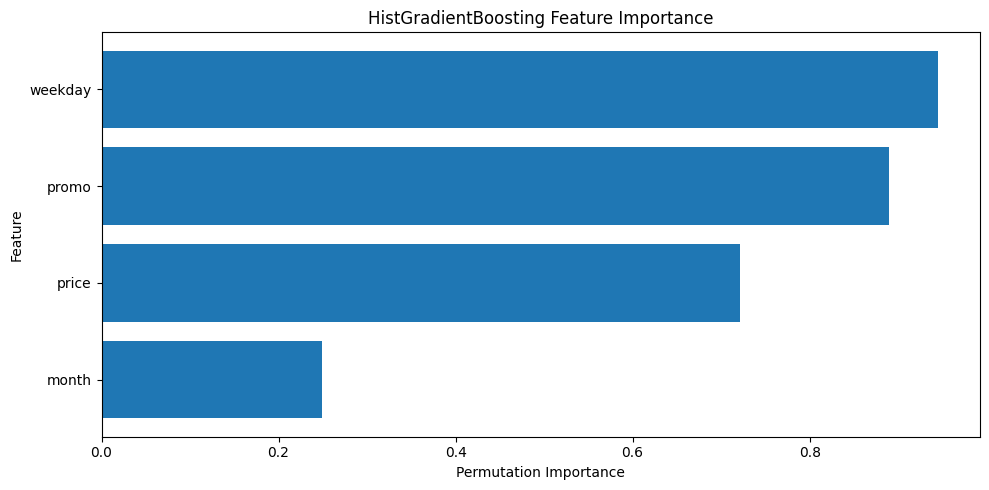

In [50]:
import matplotlib.pyplot as plt

# Assuming PROJECT_ROOT is defined in a previous cell
EDA_FIGURES_DIR = PROJECT_ROOT / "figures" / "eda"
EDA_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Mengurutkan feature importance dari yang paling rendah
# ke yang paling tinggi agar bar chart lebih mudah dibaca.
importance_plot = feature_importance.sort_values(
    "importance_mean",
    ascending=True,
)

# Membuat ukuran figure.
plt.figure(figsize=(10, 5))

# Membuat horizontal bar chart.
# Horizontal bar chart digunakan karena nama feature
# lebih mudah dibaca secara vertikal.
plt.barh(
    importance_plot["feature"],
    importance_plot["importance_mean"],
)

# Memberikan judul pada visualisasi.
plt.title("HistGradientBoosting Feature Importance")

# Memberikan label sumbu X.
plt.xlabel("Permutation Importance")

# Memberikan label sumbu Y.
plt.ylabel("Feature")

# Mengatur layout agar elemen grafik tidak terpotong.
plt.tight_layout()

# Menyimpan figure ke folder EDA/model figures.
plt.savefig(
    EDA_FIGURES_DIR / "hgb_feature_importance.png",
    dpi=150,
    bbox_inches="tight",
)

# Menampilkan grafik.
plt.show()

## Final Results

### Model Performance

| Model | Validation MAE | Validation RMSE |
|---|---:|---:|
| Baseline | 15.3451 | 20.0150 |
| Random Forest | 13.0434 | 15.8843 |
| HistGradientBoosting | **12.7804** | **15.6073** |

HistGradientBoosting achieved the best validation performance among the
evaluated models.

Compared with the baseline, HistGradientBoosting reduced MAE by
16.71% and RMSE by 22.02%.

### Final Test Performance

| Metric | Validation | Test |
|---|---:|---:|
| MAE | 12.7804 | **8.9771** |
| RMSE | 15.6073 | **11.0677** |
| WAPE | 33.45% | **33.86%** |

The lower MAE and RMSE on the test period are associated with a lower
demand level in the test period.

WAPE remained relatively consistent between validation and test,
indicating that the relative forecasting performance is more stable
than the raw MAE and RMSE values suggest.

### Feature Importance

Permutation importance identified the following feature ranking:

1. `weekday`
2. `promo`
3. `price`
4. `month`

The result indicates that weekly demand patterns, promotion status,
and price information are important inputs for demand forecasting.

### Final Modeling Decisions

- `sales` is used as the forecasting target.
- `price`, `promo`, `weekday`, and `month` are used as model features.
- A chronological train-validation-test split is used.
- Random train-test splitting is avoided.
- High-demand observations are retained.
- HistGradientBoosting is selected as the final model based on
  validation performance.
- MAE, RMSE, and WAPE are used instead of a conventional accuracy
  metric because this is a regression forecasting problem.

### 12.1 Actual vs Predicted Demand

Visualize the actual and predicted sales values on the test period.

This visualization provides an intuitive view of how well the selected
HistGradientBoosting model follows the actual demand pattern.

The visualization uses a sample of the test observations to keep the
plot readable.

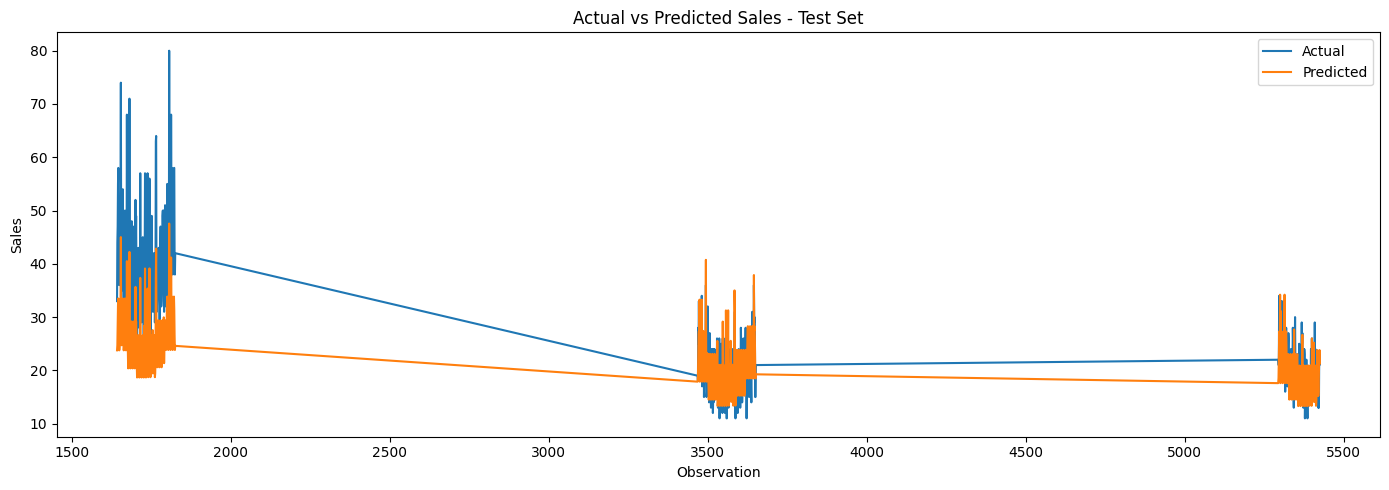

In [51]:
# Membuat DataFrame yang berisi nilai actual dan predicted.
# Index menggunakan index dari X_test agar urutan observasi tetap sama.
prediction_comparison = pd.DataFrame(
    {
        "actual": y_test,
        "predicted": hgb_test_pred,
    },
    index=X_test.index,
)

# Mengambil 500 observasi pertama dari test set.
# Kita menggunakan sample terbatas agar grafik tetap mudah dibaca.
plot_data = prediction_comparison.head(500)

# Membuat ukuran figure.
plt.figure(figsize=(14, 5))

# Menggambar nilai sales aktual.
plt.plot(
    plot_data.index,
    plot_data["actual"],
    label="Actual",
)

# Menggambar nilai sales hasil prediksi model.
plt.plot(
    plot_data.index,
    plot_data["predicted"],
    label="Predicted",
)

# Memberikan judul grafik.
plt.title("Actual vs Predicted Sales - Test Set")

# Memberikan label sumbu X.
plt.xlabel("Observation")

# Memberikan label sumbu Y.
plt.ylabel("Sales")

# Menampilkan legend agar kedua garis dapat dibedakan.
plt.legend()

# Mengatur layout agar grafik tidak terpotong.
plt.tight_layout()

# Menyimpan grafik untuk dokumentasi proyek.
plt.savefig(
    EDA_FIGURES_DIR / "actual_vs_predicted_test.png",
    dpi=150,
    bbox_inches="tight",
)

# Menampilkan grafik.
plt.show()

### 12.2 Daily Actual vs Predicted Demand

Aggregate the test predictions by date and compare the total actual
demand with the total predicted demand.

This visualization evaluates whether the model is able to follow the
overall daily demand pattern throughout the test period.

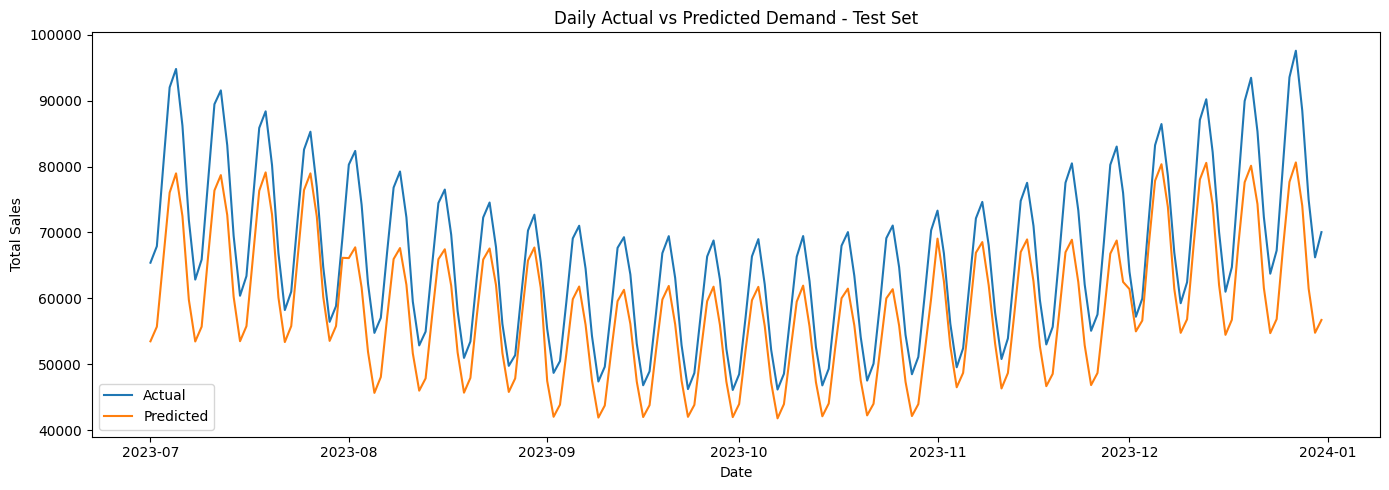

In [52]:
# Mengambil tanggal asli dari dataset berdasarkan index X_test.
# X_test masih menggunakan index asli dari dataframe utama.
test_dates = df.loc[X_test.index, "date"]

# Membuat DataFrame yang berisi tanggal, actual sales,
# dan predicted sales.
test_prediction_daily = pd.DataFrame(
    {
        "date": test_dates.values,
        "actual": y_test.values,
        "predicted": hgb_test_pred,
    }
)

# Mengelompokkan data berdasarkan tanggal.
# Karena terdapat banyak store dan item pada setiap tanggal,
# kita menjumlahkan seluruh sales untuk mendapatkan total demand harian.
test_daily = (
    test_prediction_daily
    .groupby("date")[["actual", "predicted"]]
    .sum()
)

# Memastikan tanggal tersusun secara kronologis.
test_daily = test_daily.sort_index()

# Membuat ukuran figure.
plt.figure(figsize=(14, 5))

# Menggambar total demand aktual per hari.
plt.plot(
    test_daily.index,
    test_daily["actual"],
    label="Actual",
)

# Menggambar total demand hasil prediksi per hari.
plt.plot(
    test_daily.index,
    test_daily["predicted"],
    label="Predicted",
)

# Memberikan judul grafik.
plt.title("Daily Actual vs Predicted Demand - Test Set")

# Memberikan label sumbu X.
plt.xlabel("Date")

# Memberikan label sumbu Y.
plt.ylabel("Total Sales")

# Menampilkan legend.
plt.legend()

# Mengatur layout agar grafik tidak terpotong.
plt.tight_layout()

# Menyimpan grafik untuk dokumentasi proyek.
plt.savefig(
    EDA_FIGURES_DIR / "daily_actual_vs_predicted_test.png",
    dpi=150,
    bbox_inches="tight",
)

# Menampilkan grafik.
plt.show()

# 13. Final Project Summary

## Objective

Develop a machine learning model to forecast daily product demand
using historical sales, price, promotion, and calendar information.

## Dataset

- 4,565,000 observations
- 50 stores
- 50 items
- Date range: 2019-01-01 to 2023-12-31

## Data Quality

The dataset passed the main validation checks:

- No missing calendar dates
- No duplicate store-item-date combinations
- No invalid prices
- No infinite prices
- Calendar features are temporally consistent

## Key EDA Findings

- Demand shows strong weekly patterns.
- Demand also varies by month.
- Demand differs across stores and items.
- Promotion is associated with substantially higher demand.
- Promotional periods are associated with lower prices.
- High-demand observations were retained because they may represent
  genuine demand events.

## Modeling

The forecasting target is:

- `sales`

The selected features are:

- `price`
- `promo`
- `weekday`
- `month`

A chronological split was used:

- Train: 2019-01-01 to 2022-12-31
- Validation: 2023-01-01 to 2023-06-30
- Test: 2023-07-01 to 2023-12-31

Random train-test splitting was avoided because this is a
time-series forecasting problem.

## Model Comparison

HistGradientBoosting achieved the best validation performance.

| Model | MAE | RMSE |
|---|---:|---:|
| Baseline | 15.3451 | 20.0150 |
| Random Forest | 13.0434 | 15.8843 |
| HistGradientBoosting | **12.7804** | **15.6073** |

## Final Test Performance

| Metric | Test |
|---|---:|
| MAE | **8.9771** |
| RMSE | **11.0677** |
| WAPE | **33.86%** |

The lower test MAE and RMSE are partly explained by the lower demand
level in the test period.

WAPE remained relatively close to the validation result:

- Validation WAPE: 33.45%
- Test WAPE: 33.86%

This indicates that relative forecasting performance was reasonably
consistent between validation and test periods.

## Model Interpretation

Permutation importance ranked the features as follows:

1. `weekday`
2. `promo`
3. `price`
4. `month`

The model therefore relies strongly on weekly demand patterns,
promotion information, and price information.

## Final Conclusion

HistGradientBoosting is selected as the final forecasting model based
on validation performance.

The model successfully captures the major demand patterns in the test
period, particularly the recurring weekly demand pattern.

However, the prediction plot indicates that the model tends to
underpredict some high-demand peaks.

Future improvements could include adding lag-based and rolling demand
features, store and item characteristics, and more advanced
time-series features.

## 13. Save Final Model

The HistGradientBoosting model was selected as the final forecasting
model based on its validation performance.

The trained model is saved to the project's `models/` directory so it
can be reused later for forecast generation and dashboard deployment
without retraining the model.

In [54]:
# Mengimpor joblib untuk menyimpan model machine learning
# ke dalam sebuah file.
import joblib

# Menentukan lokasi file model final.
# Model disimpan di folder models/ agar dapat digunakan kembali
# oleh proses forecasting dan dashboard.
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
model_path = MODELS_DIR / "hist_gradient_boosting.pkl"

# Menyimpan model HistGradientBoosting yang sudah dilatih.
joblib.dump(
    hgb_model,
    model_path,
)

# Menampilkan lokasi file untuk memastikan model berhasil disimpan.
print(f"Final model saved to: {model_path}")

Final model saved to: /content/drive/MyDrive/ForecastOpti/models/hist_gradient_boosting.pkl


## 14. Generate Forecast

Use the saved HistGradientBoosting model to generate demand forecasts
for the test period.

The forecast results will be saved as an output file so they can later
be consumed by the evaluation process and dashboard.

In [56]:
# Mengimpor joblib untuk membaca model yang sudah disimpan.
import joblib

# Memuat kembali model final dari folder models/.
# Dengan cara ini kita memastikan model dapat digunakan kembali
# tanpa harus melakukan training ulang.
final_model = joblib.load(
    MODELS_DIR / "hist_gradient_boosting.pkl"
)

# Menggunakan model final untuk menghasilkan prediksi
# berdasarkan feature yang tersedia pada test set.
test_forecast = final_model.predict(X_test)

# Membuat DataFrame hasil forecasting.
# Kita menyimpan tanggal, store, item, sales aktual,
# dan hasil prediksi agar output mudah digunakan kembali.
forecast_output = df.loc[
    X_test.index,
    ["date", "store_id", "item_id"]
].copy()

# Menambahkan nilai sales aktual sebagai pembanding.
forecast_output["actual_sales"] = y_test.values

# Menambahkan hasil prediksi model.
forecast_output["predicted_sales"] = test_forecast

# Menyimpan hasil forecast ke folder outputs/forecasts/.
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
forecast_path = OUTPUTS_DIR / "forecasts" / "test_forecast.csv"

# Menulis DataFrame ke file CSV tanpa menyimpan index DataFrame.
forecast_output.to_csv(
    forecast_path,
    index=False,
)

# Menampilkan informasi hasil forecasting.
print(f"Forecast rows : {len(forecast_output):,}")
print(f"Forecast saved to: {forecast_path}")

# Menampilkan beberapa baris pertama untuk memastikan
# struktur output sudah sesuai.
display(forecast_output.head())

Forecast rows : 460,000
Forecast saved to: /content/drive/MyDrive/ForecastOpti/outputs/forecasts/test_forecast.csv


,date,store_id,item_id,actual_sales,predicted_sales
1642,2023-07-01,store_1,item_1,33,23.764274
1643,2023-07-02,store_1,item_1,44,24.710509
1644,2023-07-03,store_1,item_1,47,28.430032
1645,2023-07-04,store_1,item_1,55,32.241477
1646,2023-07-05,store_1,item_1,58,33.495661


## 15. Save Evaluation Results

Save the final model evaluation metrics as a structured output.

The evaluation results include MAE, RMSE, and WAPE for the test period.

These metrics will be reused later by the dashboard and portfolio
documentation.

In [57]:
# Mengimpor metric yang digunakan untuk mengevaluasi
# hasil forecasting.
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Menghitung Mean Absolute Error (MAE).
# MAE menunjukkan rata-rata selisih absolut antara
# sales aktual dan sales hasil prediksi.
test_mae = mean_absolute_error(
    forecast_output["actual_sales"],
    forecast_output["predicted_sales"],
)

# Menghitung Root Mean Squared Error (RMSE).
# RMSE memberikan penalti lebih besar terhadap error yang besar.
test_rmse = mean_squared_error(
    forecast_output["actual_sales"],
    forecast_output["predicted_sales"],
) ** 0.5

# Menghitung Weighted Absolute Percentage Error (WAPE).
# WAPE membandingkan total absolute error dengan
# total actual demand.
test_wape = (
    abs(
        forecast_output["actual_sales"]
        - forecast_output["predicted_sales"]
    ).sum()
    / forecast_output["actual_sales"].sum()
)

# Membuat DataFrame berisi metric evaluasi.
# Struktur ini memudahkan hasil evaluasi disimpan dan
# digunakan kembali oleh dashboard.
evaluation_output = pd.DataFrame(
    {
        "dataset": ["test"],
        "mae": [test_mae],
        "rmse": [test_rmse],
        "wape": [test_wape],
    }
)

# Menentukan lokasi file evaluation.
evaluation_path = (
    OUTPUTS_DIR
    / "evaluation"
    / "test_evaluation.csv"
)

# Menyimpan hasil evaluasi sebagai CSV.
evaluation_output.to_csv(
    evaluation_path,
    index=False,
)

# Menampilkan hasil evaluasi agar kita dapat memastikan
# nilainya sesuai dengan hasil yang sudah kita peroleh sebelumnya.
display(evaluation_output)

# Menampilkan lokasi file hasil evaluasi.
print(f"Evaluation saved to: {evaluation_path}")

,dataset,mae,rmse,wape
0,test,8.977142,11.067669,0.338632


Evaluation saved to: /content/drive/MyDrive/ForecastOpti/outputs/evaluation/test_evaluation.csv


## 16. Prepare Dashboard Data

Prepare a daily demand dataset for dashboard visualization.

The dashboard will use the generated forecast output to display actual
and predicted demand over time.

The data is aggregated by date so the dashboard can focus on overall
demand trends rather than individual store-item observations.

In [58]:
# Menggunakan hasil forecast yang sudah kita simpan di
# forecast_output sebagai sumber data dashboard.
dashboard_daily = (
    forecast_output
    .groupby("date")
    .agg(
        actual_sales=("actual_sales", "sum"),
        predicted_sales=("predicted_sales", "sum"),
    )
    .reset_index()
)

# Memastikan data tersusun berdasarkan tanggal.
# Ini penting untuk visualisasi time series di dashboard.
dashboard_daily = dashboard_daily.sort_values(
    "date"
)

# Menentukan lokasi penyimpanan data dashboard.
dashboard_data_path = (
    OUTPUTS_DIR
    / "forecasts"
    / "daily_forecast_summary.csv"
)

# Menyimpan ringkasan daily forecast sebagai CSV.
# File ini nantinya dapat dibaca langsung oleh dashboard.
dashboard_daily.to_csv(
    dashboard_data_path,
    index=False,
)

# Menampilkan informasi jumlah tanggal yang tersedia.
print(f"Dashboard rows : {len(dashboard_daily):,}")

# Menampilkan lokasi file.
print(f"Dashboard data saved to: {dashboard_data_path}")

# Menampilkan beberapa baris pertama untuk memastikan
# struktur data sudah benar.
display(dashboard_daily.head())

Dashboard rows : 184
Dashboard data saved to: /content/drive/MyDrive/ForecastOpti/outputs/forecasts/daily_forecast_summary.csv


,date,actual_sales,predicted_sales
0,2023-07-01,65408,53471.901088
1,2023-07-02,67904,55685.877867
2,2023-07-03,80101,65957.865809
3,2023-07-04,92037,76054.386510
4,2023-07-05,94833,78976.218167


## 17. Run Dashboard

Run the Streamlit application and verify that the dashboard can load
the forecasting and evaluation outputs generated by the project.

In [60]:
# Menginstal Streamlit ke environment Google Colab.
# Streamlit diperlukan untuk menjalankan dashboard ForecastOpti.
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 89.8 MB/s eta 0:00:00


In [61]:
# Memeriksa versi Streamlit yang sudah terpasang.
# Jika versi muncul, berarti Streamlit sudah tersedia.
!streamlit --version

Streamlit, version 1.61.1


In [4]:
# Mengunduh Cloudflare Tunnel untuk Linux.
# Tunnel ini digunakan untuk membuat koneksi dari browser
# ke aplikasi Streamlit yang berjalan di Google Colab.
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 \
    -O /content/cloudflared

# Memberikan permission agar file cloudflared dapat dijalankan.
!chmod +x /content/cloudflared

In [5]:
# Menjalankan Cloudflare Tunnel ke aplikasi Streamlit.
# Streamlit kita berjalan pada port 8501.
#
# nohup membuat proses tunnel tetap berjalan di background
# sehingga cell notebook tidak harus menunggu proses selesai.
# Output tunnel disimpan ke file log agar URL publik dapat kita baca.
!nohup /content/cloudflared tunnel --url http://127.0.0.1:8501 \
    > /content/cloudflared.log 2>&1 &

# Memberikan waktu beberapa detik kepada cloudflared
# untuk membuat koneksi tunnel.
import time
time.sleep(5)

# Membaca log untuk mendapatkan URL publik dari tunnel.
!cat /content/cloudflared.log

2026-08-10T19:40:34Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-08-10T19:40:34Z INF Requesting new quick Tunnel on trycloudflare.com...


In [6]:
# Mengimpor time agar kita dapat memberikan waktu
# kepada Cloudflare Tunnel untuk menyelesaikan proses koneksi.
import time

# Menunggu beberapa detik sebelum membaca log terbaru.
time.sleep(5)

# Membaca log Cloudflare Tunnel.
# Kita mencari URL trycloudflare.com yang diberikan
# untuk mengakses dashboard dari browser.
!cat /content/cloudflared.log

2026-08-10T19:40:34Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-08-10T19:40:34Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-08-10T19:40:41Z INF +--------------------------------------------------------------------------------------------+
2026-08-10T19:40:41Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-08-10T19:40:41Z INF |  https://consider-reduce-avatar-lodge.trycloudflare.co

In [7]:
# Memeriksa apakah aplikasi Streamlit masih berjalan
# pada port 8501.
!curl -I http://127.0.0.1:8501

curl: (7) Failed to connect to 127.0.0.1 port 8501 after 0 ms: Connection refused


In [8]:
# Menampilkan proses yang sedang menggunakan port 8501.
# Jika Streamlit masih berjalan, kita akan melihat proses
# yang berkaitan dengan streamlit pada output.
!ps aux | grep streamlit

root       16075  0.0  0.0   7376  3348 ?        S    19:42   0:00 /bin/bash -c ps aux | grep streamlit
root       16077  0.0  0.0   6484  2312 ?        S    19:42   0:00 grep streamlit


In [9]:
# Masuk ke folder utama project ForecastOpti.
# Ini memastikan path src/dashboard.py ditemukan dengan benar.
%cd /content/drive/MyDrive/ForecastOpti

# Menjalankan Streamlit sebagai proses background.
# Output aplikasi diarahkan ke file log agar kita dapat
# melihat apakah ada error saat proses startup.
!nohup streamlit run src/dashboard.py \
    --server.port 8501 \
    --server.address 127.0.0.1 \
    > /content/streamlit.log 2>&1 &

# Mengimpor time untuk memberikan waktu kepada Streamlit
# menyelesaikan proses startup.
import time

# Menunggu 5 detik sebelum melakukan pengecekan.
time.sleep(5)

# Menampilkan log Streamlit.
# Jika ada error pada dashboard.py, error tersebut akan terlihat di sini.
print("=== STREAMLIT LOG ===")
!cat /content/streamlit.log

# Memeriksa apakah port 8501 sudah menerima koneksi.
print("\n=== PORT CHECK ===")
!curl -I http://127.0.0.1:8501

/content/drive/MyDrive/ForecastOpti
=== STREAMLIT LOG ===


2026-08-10 19:43:22.798 Uvicorn server started on 127.0.0.1:8501

  You can now view your Streamlit app in your browser.

  URL: http://127.0.0.1:8501


=== PORT CHECK ===
HTTP/1.1 200 OK
date: Mon, 10 Aug 2026 19:43:22 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 10951
last-modified: Mon, 10 Aug 2026 19:35:06 GMT
etag: "3f402ac02681c48c7080f216ab77253b"
cache-control: no-cache

